In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/icr-identify-age-related-conditions/sample_submission.csv
/kaggle/input/icr-identify-age-related-conditions/greeks.csv
/kaggle/input/icr-identify-age-related-conditions/train.csv
/kaggle/input/icr-identify-age-related-conditions/test.csv


I'll start with implementing a simple logistic regression model, followed by random forest and then XGB. 

First, I'll import the needed packages:

In [2]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
import sklearn.metrics.cluster as smc
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression
from sklearn.metrics import log_loss
from sklearn.impute import SimpleImputer


from matplotlib import pyplot
import itertools

%matplotlib inline

import random

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Assigning the dataframe:

In [3]:
df=pd.read_csv("/kaggle/input/icr-identify-age-related-conditions/train.csv")
df

,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,...,FL,FR,FS,GB,GE,GF,GH,GI,GL,Class
0,000ff2bfdfe9,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,...,7.298162,1.73855,0.094822,11.339138,72.611063,2003.810319,22.136229,69.834944,0.120343,1
1,007255e47698,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,...,0.173229,0.49706,0.568932,9.292698,72.611063,27981.562750,29.135430,32.131996,21.978000,0
2,013f2bd269f5,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,...,7.709560,0.97556,1.198821,37.077772,88.609437,13676.957810,28.022851,35.192676,0.196941,0
3,043ac50845d5,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,...,6.122162,0.49706,0.284466,18.529584,82.416803,2094.262452,39.948656,90.493248,0.155829,0
4,044fb8a146ec,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,...,8.153058,48.50134,0.121914,16.408728,146.109943,8524.370502,45.381316,36.262628,0.096614,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,fd3dafe738fd,0.149555,3130.05946,123.763599,9.513984,13.020852,3.499305,0.077343,8.545512,2.804172,...,0.173229,1.26092,0.067730,8.967128,217.148554,8095.932828,24.640462,69.191944,21.978000,0
613,fd895603f071,0.435846,5462.03438,85.200147,46.551007,15.973224,5.979825,0.025882,12.622906,3.777550,...,10.223150,1.24236,0.426699,35.896418,496.994214,3085.308063,29.648928,124.808872,0.145340,0
614,fd8ef6377f76,0.427300,2459.10720,130.138587,55.355778,10.005552,8.070549,0.025578,15.408390,1.229900,...,0.173229,0.49706,0.067730,19.962092,128.896894,6474.652866,26.166072,119.559420,21.978000,0
615,fe1942975e40,0.363205,1263.53524,85.200147,23.685856,8.138688,7.981959,0.025578,7.524588,1.229900,...,9.256996,0.78764,0.670527,24.594488,72.611063,1965.343176,25.116750,37.155112,0.184622,0


I'll get started with pre-processing the data first.

Now, I will be looking at the dataframe to see which parts I should remove or augment:

In [4]:
df.describe()

,AB,AF,AH,AM,AR,AX,AY,AZ,BC,BD,...,FL,FR,FS,GB,GE,GF,GH,GI,GL,Class
count,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,...,616.000000,617.000000,615.000000,617.000000,617.000000,617.000000,617.000000,617.000000,616.000000,617.000000
mean,0.477149,3502.013221,118.624513,38.968552,10.128242,5.545576,0.060320,10.566447,8.053012,5350.388655,...,5.433199,3.533905,0.421501,20.724856,131.714987,14679.595398,31.489716,50.584437,8.530961,0.175041
std,0.468388,2300.322717,127.838950,69.728226,10.518877,2.551696,0.416817,4.350645,65.166943,3021.326641,...,11.496257,50.181948,1.305365,9.991907,144.181524,19352.959387,9.864239,36.266251,10.327010,0.380310
min,0.081187,192.593280,85.200147,3.177522,8.138688,0.699861,0.025578,3.396778,1.229900,1693.624320,...,0.173229,0.497060,0.067730,4.102182,72.611063,13.038894,9.432735,0.897628,0.001129,0.000000
25%,0.252107,2197.345480,85.200147,12.270314,8.138688,4.128294,0.025578,8.129580,1.229900,4155.702870,...,0.173229,0.497060,0.067730,14.036718,72.611063,2798.992584,25.034888,23.011684,0.124392,0.000000
50%,0.354659,3120.318960,85.200147,20.533110,8.138688,5.031912,0.025578,10.461320,1.229900,4997.960730,...,3.028141,1.131000,0.250601,18.771436,72.611063,7838.273610,30.608946,41.007968,0.337827,0.000000
75%,0.559763,4361.637390,113.739540,39.139886,8.138688,6.431634,0.036845,12.969516,5.081244,6035.885700,...,6.238814,1.512060,0.535067,25.608406,127.591671,19035.709240,36.863947,67.931664,21.978000,0.000000
max,6.161666,28688.187660,1910.123198,630.518230,178.943634,38.270880,10.315851,38.971568,1463.693448,53060.599240,...,137.932739,1244.227020,31.365763,135.781294,1497.351958,143790.071200,81.210825,191.194764,21.978000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 58 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      617 non-null    object 
 1   AB      617 non-null    float64
 2   AF      617 non-null    float64
 3   AH      617 non-null    float64
 4   AM      617 non-null    float64
 5   AR      617 non-null    float64
 6   AX      617 non-null    float64
 7   AY      617 non-null    float64
 8   AZ      617 non-null    float64
 9   BC      617 non-null    float64
 10  BD      617 non-null    float64
 11  BN      617 non-null    float64
 12  BP      617 non-null    float64
 13  BQ      557 non-null    float64
 14  BR      617 non-null    float64
 15  BZ      617 non-null    float64
 16  CB      615 non-null    float64
 17  CC      614 non-null    float64
 18  CD      617 non-null    float64
 19  CF      617 non-null    float64
 20  CH      617 non-null    float64
 21  CL      617 non-null    float64
 22  CR

The code below was influenced by the "Age-Related Conditions Regression(Accuracy=.99)" Notebook, by Swathi Menon. 

Thank you to Swathi Menon for creating such a well-written and informative notebook!

In [6]:
# converting or dropping the values that aren't in int or float form
df.drop(["Id"],inplace=True,axis=1)
le=LabelEncoder()
df["EJ"]=le.fit_transform(df["EJ"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 57 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AB      617 non-null    float64
 1   AF      617 non-null    float64
 2   AH      617 non-null    float64
 3   AM      617 non-null    float64
 4   AR      617 non-null    float64
 5   AX      617 non-null    float64
 6   AY      617 non-null    float64
 7   AZ      617 non-null    float64
 8   BC      617 non-null    float64
 9   BD      617 non-null    float64
 10  BN      617 non-null    float64
 11  BP      617 non-null    float64
 12  BQ      557 non-null    float64
 13  BR      617 non-null    float64
 14  BZ      617 non-null    float64
 15  CB      615 non-null    float64
 16  CC      614 non-null    float64
 17  CD      617 non-null    float64
 18  CF      617 non-null    float64
 19  CH      617 non-null    float64
 20  CL      617 non-null    float64
 21  CR      617 non-null    float64
 22  CS

In [7]:
# checking to see if there are any null values
df.isna().sum()

AB        0
AF        0
AH        0
AM        0
AR        0
AX        0
AY        0
AZ        0
BC        0
BD        0
BN        0
BP        0
BQ       60
BR        0
BZ        0
CB        2
CC        3
CD        0
CF        0
CH        0
CL        0
CR        0
CS        0
CU        0
CW        0
DA        0
DE        0
DF        0
DH        0
DI        0
DL        0
DN        0
DU        1
DV        0
DY        0
EB        0
EE        0
EG        0
EH        0
EJ        0
EL       60
EP        0
EU        0
FC        1
FD        0
FE        0
FI        0
FL        1
FR        0
FS        2
GB        0
GE        0
GF        0
GH        0
GI        0
GL        1
Class     0
dtype: int64

<Axes: ylabel='Class'>

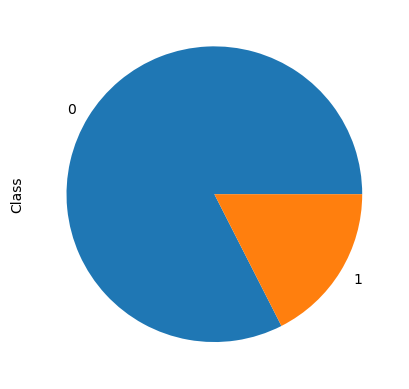

In [8]:
df.dropna(inplace=True,axis=1)
a=df['Class'].value_counts()
a
# plotting a pie chart
plot_df = df.Class.value_counts()
plot_df.plot(kind="pie")

In [9]:
# formatting
X=df.iloc[:,:-1]
X

,AB,AF,AH,AM,AR,AX,AY,AZ,BC,BD,...,EU,FD,FE,FI,FR,GB,GE,GF,GH,GI
0,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,4126.58731,...,3.828384,10.265073,9028.291921,3.583450,1.73855,11.339138,72.611063,2003.810319,22.136229,69.834944
1,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,5496.92824,...,52.260480,0.296850,6785.003474,10.358927,0.49706,9.292698,72.611063,27981.562750,29.135430,32.131996
2,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,5135.78024,...,5.390628,8.745201,8338.906181,11.626917,0.97556,37.077772,88.609437,13676.957810,28.022851,35.192676
3,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,4169.67738,...,31.323372,7.884336,10965.766040,14.852022,0.49706,18.529584,82.416803,2094.262452,39.948656,90.493248
4,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,5728.73412,...,51.141336,4.274640,16198.049590,13.666727,48.50134,16.408728,146.109943,8524.370502,45.381316,36.262628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,0.149555,3130.05946,123.763599,9.513984,13.020852,3.499305,0.077343,8.545512,2.804172,4157.68439,...,65.821872,0.296850,17167.209610,9.879296,1.26092,8.967128,217.148554,8095.932828,24.640462,69.191944
613,0.435846,5462.03438,85.200147,46.551007,15.973224,5.979825,0.025882,12.622906,3.777550,5654.07556,...,447.657600,6.067614,18460.330020,10.910227,1.24236,35.896418,496.994214,3085.308063,29.648928,124.808872
614,0.427300,2459.10720,130.138587,55.355778,10.005552,8.070549,0.025578,15.408390,1.229900,5888.87769,...,3.828384,0.296850,5088.922912,12.029366,0.49706,19.962092,128.896894,6474.652866,26.166072,119.559420
615,0.363205,1263.53524,85.200147,23.685856,8.138688,7.981959,0.025578,7.524588,1.229900,4517.86560,...,8.259384,6.192291,6464.250832,8.026928,0.78764,24.594488,72.611063,1965.343176,25.116750,37.155112


In [10]:
y=df.iloc[:,-1]
y

0      1
1      0
2      0
3      0
4      1
      ..
612    0
613    0
614    0
615    0
616    0
Name: Class, Length: 617, dtype: int64

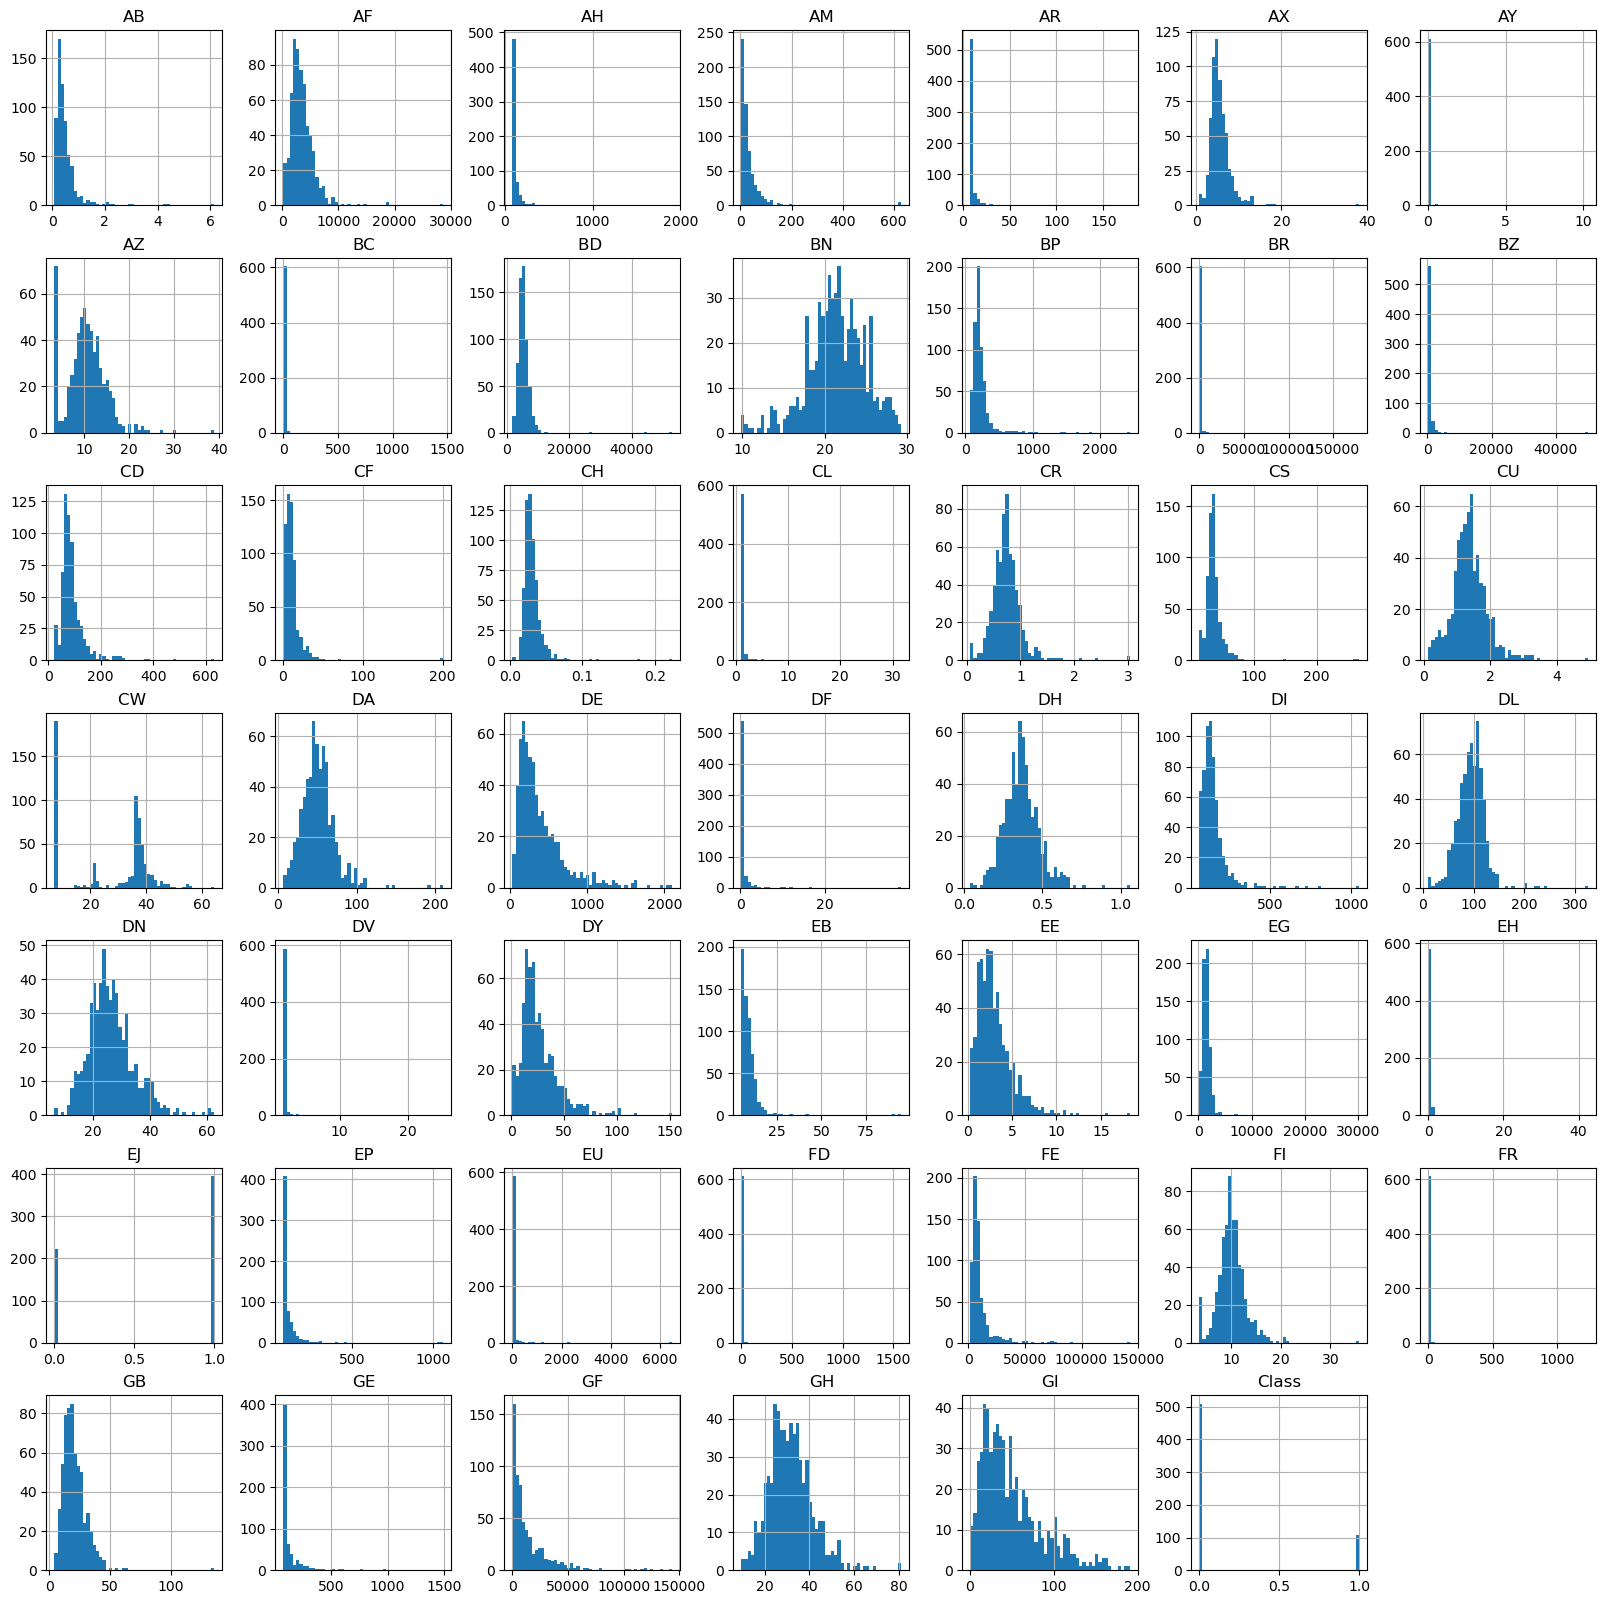

In [11]:
# getting an idea of the distribution of each factor
df.hist(bins=50, figsize = [20,20])
pyplot.show()

In [12]:
# selecting the 25 best features with Anova
selector=SelectKBest(score_func=f_classif, k=25)

X_selected = selector.fit_transform(X,y)

# Get the selected feature indices
feature_indices = selector.get_support(indices=True)

# Get the names of the selected features
selected_features = X.columns[feature_indices]

# Create a new DataFrame with only the selected features
selected_data = df[selected_features]
# Print the selected features
print(selected_features)

Index(['AB', 'AF', 'AM', 'AX', 'BC', 'BD ', 'BN', 'BP', 'BZ', 'CD ', 'CF',
       'CR', 'DA', 'DE', 'DH', 'DI', 'DL', 'EE', 'EH', 'EJ', 'FD ', 'FE', 'FI',
       'FR', 'GF'],
      dtype='object')


In [13]:
# Select only the desired variables
selected_variables = ['AB', 'AF', 'AM', 'AX', 'BC', 'BD ', 'BN', 'BP', 'BZ', 'CD ', 'CF',
       'CR', 'DA', 'DE', 'DH', 'DI', 'DL', 'EE', 'EH', 'EJ', 'FD ', 'FE', 'FI',
       'FR', 'GF']
x = df[selected_variables]

# Display the resulting DataFrame
print(x)

           AB          AF          AM        AX          BC         BD   \
0    0.209377  3109.03329   22.394407  0.699861    5.555634  4126.58731   
1    0.145282   978.76416   36.968889  3.632190    1.229900  5496.92824   
2    0.470030  2635.10654   32.360553  6.732840    1.229900  5135.78024   
3    0.252107  3819.65177   77.112203  3.685344    1.229900  4169.67738   
4    0.380297  3733.04844   14.103738  3.942255  102.151980  5728.73412   
..        ...         ...         ...       ...         ...         ...   
612  0.149555  3130.05946    9.513984  3.499305    2.804172  4157.68439   
613  0.435846  5462.03438   46.551007  5.979825    3.777550  5654.07556   
614  0.427300  2459.10720   55.355778  8.070549    1.229900  5888.87769   
615  0.363205  1263.53524   23.685856  7.981959    1.229900  4517.86560   
616  0.482849  2672.53426  112.006102  3.198099    7.948668  2818.01707   

          BN          BP          BZ         CD   ...          DI         DL  \
0    22.5984  175.6

In [14]:
sm=RandomOverSampler()
x,y=sm.fit_resample(x,y)
# regularization of the data
ms=MinMaxScaler()
Xsc=ms.fit_transform(x)
Xsc

array([[0.02108222, 0.10234705, 0.03063229, ..., 0.        , 0.0009982 ,
        0.01384624],
       [0.01054111, 0.02758921, 0.05386446, ..., 0.20997779, 0.        ,
        0.19452706],
       [0.0639494 , 0.08571547, 0.04651863, ..., 0.24927388, 0.00038473,
        0.09503548],
       ...,
       [0.06465214, 0.16440956, 0.05071977, ..., 0.30702204, 0.00046681,
        0.01728152],
       [0.03162333, 0.12729928, 0.00789627, ..., 0.22620878, 0.        ,
        0.01179632],
       [0.06254392, 0.14252709, 0.10751664, ..., 0.15598838, 0.00192901,
        0.07034554]])

Time to split, test, and train the data:

In [15]:
X_train,X_test,y_train,y_test=train_test_split(Xsc,y,test_size=0.1,random_state=4)

In [16]:
log_reg = LogisticRegression(C = 0.5)
log_reg.fit(X_train, y_train)
log_predicted = log_reg.predict(X_test)
log_score = log_reg.predict_proba(X_test)[:,1]

In [17]:
print(classification_report(y_test,log_predicted))
print(log_loss(y_test, log_predicted))


              precision    recall  f1-score   support

           0       0.79      0.86      0.82        49
           1       0.86      0.79      0.82        53

    accuracy                           0.82       102
   macro avg       0.82      0.82      0.82       102
weighted avg       0.83      0.82      0.82       102

6.360644715726556


Logistic Model Performance Results:

AUC of ROC:  0.9048902579899885


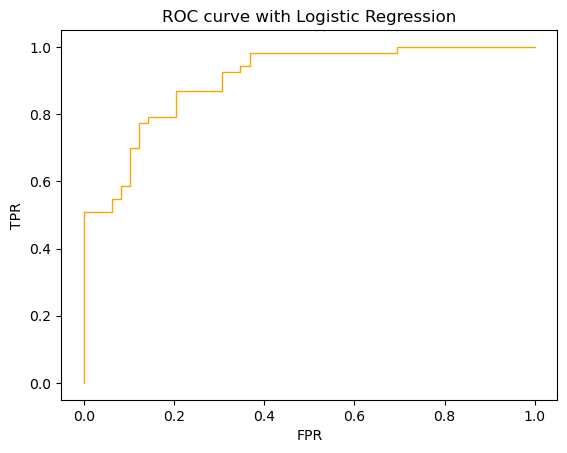

In [18]:
# plotting the ROC curve, and finding AUC
fpr_log_reg, tpr_log_reg, thresholds = metrics.roc_curve(y_test,log_score)
print("Logistic Model Performance Results:\n")
pyplot.figure(1)
pyplot.plot(fpr_log_reg, tpr_log_reg, color='orange', lw=1)
pyplot.title("ROC curve with Logistic Regression")
pyplot.xlabel('FPR')
pyplot.ylabel('TPR')



# report auc
# use metrics.auc(fpr, tpr)
aucroc = metrics.auc(fpr_log_reg, tpr_log_reg)
print('AUC of ROC: ', aucroc)

As you can see, the score is not very high.

Now, we can try using a Random Forest Classifier Model instead:

In [19]:
rf=RandomForestClassifier(criterion= 'entropy', max_depth= None, min_samples_leaf= 1, min_samples_split= 4,n_estimators= 200)
rf.fit(X_train,y_train)
y_pred4=rf.predict(X_test)
y_pred4

array([1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1])

In [20]:
print(classification_report(y_test,y_pred4))
print(log_loss(y_test, y_pred4))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        49
           1       0.98      1.00      0.99        53

    accuracy                           0.99       102
   macro avg       0.99      0.99      0.99       102
weighted avg       0.99      0.99      0.99       102

0.3533691508736978


Random Forest Classifier Performance Results:

AUC of ROC:  0.9897959183673469


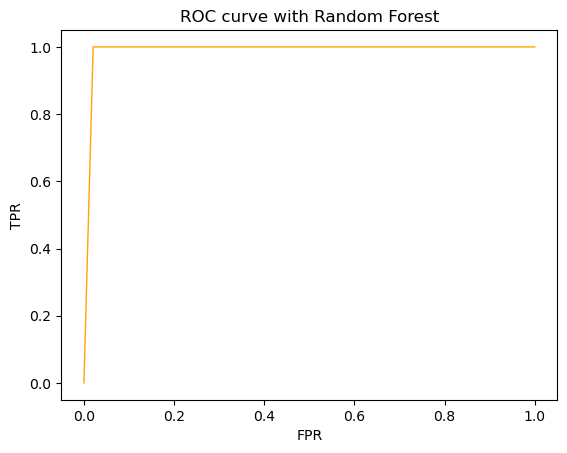

In [21]:
# plotting the ROC curve, and finding AUC
fpr_log_reg, tpr_log_reg, thresholds = metrics.roc_curve(y_test,y_pred4)
print("Random Forest Classifier Performance Results:\n")
pyplot.figure(1)
pyplot.plot(fpr_log_reg, tpr_log_reg, color='orange', lw=1)
pyplot.title("ROC curve with Random Forest")
pyplot.xlabel('FPR')
pyplot.ylabel('TPR')



# report auc
# use metrics.auc(fpr, tpr)
aucroc = metrics.auc(fpr_log_reg, tpr_log_reg)
print('AUC of ROC: ', aucroc)

Wow, we have achieved a very high AUC!
Now, I'll use an XGB Classifier Model:

In [22]:
xgb=XGBClassifier()
xgb.fit(X_train,y_train)
y_pred7=xgb.predict(X_test)
y_pred7

print(classification_report(y_test,y_pred7))
print(log_loss(y_test, y_pred7))


              precision    recall  f1-score   support

           0       1.00      0.98      0.99        49
           1       0.98      1.00      0.99        53

    accuracy                           0.99       102
   macro avg       0.99      0.99      0.99       102
weighted avg       0.99      0.99      0.99       102

0.3533691508736978


XGBoost Performance Results:

AUC of ROC:  0.9897959183673469


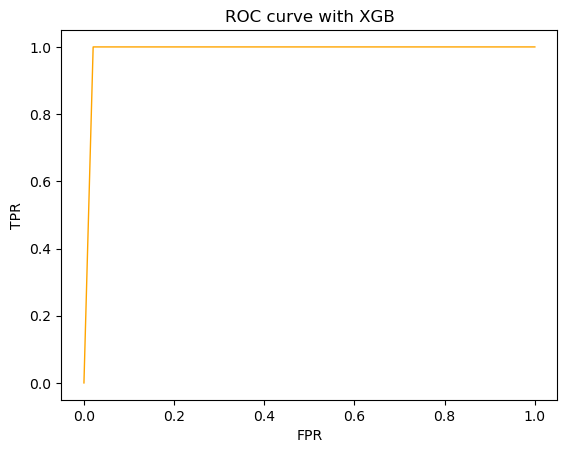

In [23]:
# plotting the ROC curve, and finding AUC
fpr_log_reg, tpr_log_reg, thresholds = metrics.roc_curve(y_test, y_pred7)
print("XGBoost Performance Results:\n")
pyplot.figure(1)
pyplot.plot(fpr_log_reg, tpr_log_reg, color='orange', lw=1)
pyplot.title("ROC curve with XGB")
pyplot.xlabel('FPR')
pyplot.ylabel('TPR')



# report auc
# use metrics.auc(fpr, tpr)
aucroc = metrics.auc(fpr_log_reg, tpr_log_reg)
print('AUC of ROC: ', aucroc)

It looks like I achieved the highest accuracy score and lowest log loss with the Random Forest Model.

Now, it's time to submit my results.

In [24]:
# this is the required format for submission
DF=pd.read_csv("/kaggle/input/icr-identify-age-related-conditions/sample_submission.csv")
DF

,Id,class_0,class_1
0,00eed32682bb,0.5,0.5
1,010ebe33f668,0.5,0.5
2,02fa521e1838,0.5,0.5
3,040e15f562a2,0.5,0.5
4,046e85c7cc7f,0.5,0.5


In [25]:
df_test=pd.read_csv(r'/kaggle/input/icr-identify-age-related-conditions/test.csv')

test_data_ids = df_test["Id"].values

df_test.head()

,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,...,FI,FL,FR,FS,GB,GE,GF,GH,GI,GL
0,00eed32682bb,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,010ebe33f668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,02fa521e1838,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,040e15f562a2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,046e85c7cc7f,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
le=LabelEncoder()
df_test["EJ"]=le.fit_transform(df_test["EJ"])
df_test.dropna(inplace=True,axis=1)
selected_variables = ['AB', 'AF', 'AM', 'AX', 'BC', 'BD ', 'BN', 'BP', 'BZ', 'CD ', 'CF',
       'CR', 'DA', 'DE', 'DH', 'DI', 'DL', 'EE', 'EH', 'EJ', 'FD ', 'FE', 'FI',
       'FR', 'GF']
x = df_test[selected_variables]

# regularization of the data
ms=MinMaxScaler()
Xsc_test=ms.fit_transform(x)
Xsc_test
df_test = Xsc_test

In [27]:
probabilities = rf.predict_proba(df_test)

probabilities_class_0 = probabilities[:,0]
probabilities_class_1 = probabilities[:,1]

# Create a DataFrame for submission
submission_df = pd.DataFrame()

# Load the test data Ids into the DataFrame
submission_df["Ids"] = test_data_ids

print(test_data_ids)
print(probabilities_class_0)
print(probabilities_class_1)


# Assign the probabilities to the respective columns
submission_df['class_0'] = probabilities_class_0
submission_df['class_1'] = probabilities_class_1

# Save the DataFrame to a CSV file for submission
submission_df.to_csv('submission.csv', index=False)

submission_df

['00eed32682bb' '010ebe33f668' '02fa521e1838' '040e15f562a2'
 '046e85c7cc7f']
[0.67208333 0.67208333 0.67208333 0.67208333 0.67208333]
[0.32791667 0.32791667 0.32791667 0.32791667 0.32791667]


,Ids,class_0,class_1
0,00eed32682bb,0.672083,0.327917
1,010ebe33f668,0.672083,0.327917
2,02fa521e1838,0.672083,0.327917
3,040e15f562a2,0.672083,0.327917
4,046e85c7cc7f,0.672083,0.327917


Thank you for reading my notebook.

I hope this helps!